In [1]:
import ROOT
import os,sys,json
import argparse
from datetime import date    
import numpy as np
import copy
import math
from tqdm import tqdm
import mplhep as hep
import matplotlib.pyplot as plt
ROOT.gROOT.SetBatch(1)
hep.style.use("CMS")

def getValues(histo):
    values = []
    bins = []
    for n in range(1, histo.GetNbinsX()+1):
        values.append(histo.GetBinContent(n))
        bins.append(histo.GetBinLowEdge(n))
    bins.append(histo.GetBinLowEdge(n) + histo.GetBinWidth(n))
    return np.array(values), np.array(bins)

Welcome to JupyROOT 6.24/07


# Data studies per era and displacement

In [2]:
portion = '2022'
#baseDir = '/ceph/cms/store/user/fernance/EXO-24-016/Data-studies/'

# List of data eras for which you want to make the plot
samples = []
if portion =='2022':
    inDir = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-23-2025_2022_noMasking'
    #
    samples.append(['2022', 'Data'])
    samples.append(['2022', 'DataC'])
    samples.append(['2022', 'DataD'])
    samples.append(['2022', 'DataE'])
    samples.append(['2022', 'DataF'])
    samples.append(['2022', 'DataG'])
elif portion == '2023':
    inDir = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-23-2025_2023_noMasking'
    #
    samples.append(['2023', 'Data'])
    samples.append(['2023', 'DataC-triggerV10'])
    samples.append(['2023', 'DataC'])
    samples.append(['2023', 'DataD'])

lumi = {}
lumi['2022_Data'] = 5.070714851 + 3.006332096 + 5.866801170 + 18.006671456 + 3.108858306
lumi['2022_DataC'] = 5.070714851
lumi['2022_DataD'] = 3.006332096
lumi['2022_DataE'] = 5.866801170 
lumi['2022_DataF'] = 18.006671456
lumi['2022_DataG'] = 3.108858306
lumi['2023_Data'] = 5.557004785 + 11.503479528 + 9.525199061
lumi['2023_DataC-triggerV10'] = 5.557004785
lumi['2023_DataC'] = 11.503479528
lumi['2023_DataD'] = 9.525199061
    
# List of histograms you want to include in each plot
hnn = []
hnn.append('d_Dimuon_full_inclusive')
hnn.append('d_Dimuon_lxy0p0to0p2_inclusive')
hnn.append('d_Dimuon_lxy0p2to1p0_inclusive')
hnn.append('d_Dimuon_lxy1p0to2p4_inclusive')
hnn.append('d_Dimuon_lxy2p4to3p1_inclusive')
hnn.append('d_Dimuon_lxy3p1to7p0_inclusive')
hnn.append('d_Dimuon_lxy7p0to11p0_inclusive')
hnn.append('d_Dimuon_lxy11p0to16p0_inclusive')
hnn.append('d_Dimuon_lxy16p0to70p0_inclusive')

# Labels for those histograms
legnames = {}
legnames['d_Dimuon_full_inclusive']  = r'Inclusive'
legnames['d_Dimuon_lxy0p0to0p2_inclusive']  = r'$l_{xy} \in [0.0, 0.2]$ cm'
legnames['d_Dimuon_lxy0p2to1p0_inclusive']  = r'$l_{xy} \in [0.2, 1.0]$ cm'
legnames['d_Dimuon_lxy1p0to2p4_inclusive']  = r'$l_{xy} \in [1.0, 2.4]$ cm'
legnames['d_Dimuon_lxy2p4to3p1_inclusive']  = r'$l_{xy} \in [2.4, 3.1]$ cm'
legnames['d_Dimuon_lxy3p1to7p0_inclusive']  = r'$l_{xy} \in [3.1, 7.0]$ cm'
legnames['d_Dimuon_lxy7p0to11p0_inclusive']  = r'$l_{xy} \in [7.0, 11.0]$ cm'
legnames['d_Dimuon_lxy11p0to16p0_inclusive']  = r'$l_{xy} \in [11.0, 16.0]$ cm'
legnames['d_Dimuon_lxy16p0to70p0_inclusive']  = r'$l_{xy} \in [16.0, 70.0]$ cm'
#
legnames['2022_Data']  = 'Full 2022 Data'
legnames['2022_DataC']  = '2022 Data (era C)'
legnames['2022_DataD']  = '2022 Data (era D)'
legnames['2022_DataE']  = '2022 Data (era E)'
legnames['2022_DataF']  = '2022 Data (era F)'
legnames['2022_DataG']  = '2022 Data (era G)'
#
legnames['2023_Data']  = 'Full 2023 Data'
legnames['2023_DataC-triggerV10']  = '2023 Data (era C, first period)'
legnames['2023_DataC']  = '2023 Data (era C, second period)'
legnames['2023_DataD']  = '2023 Data (era D)'

# Colors (as per CAT guidelines)
colors = ["k","#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"]

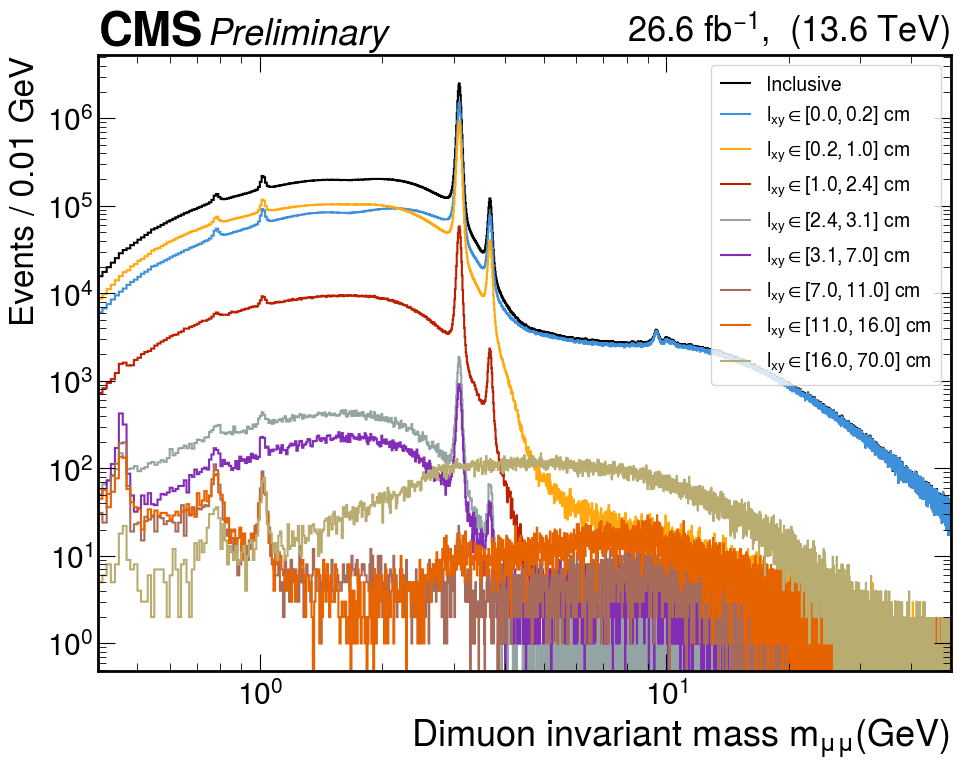

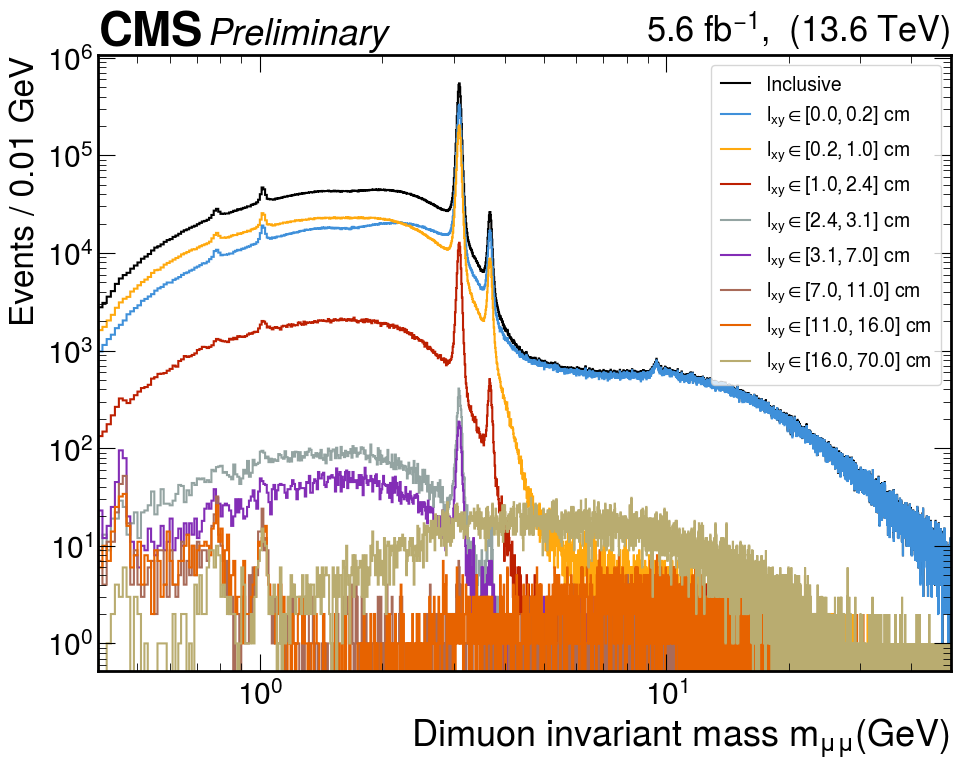

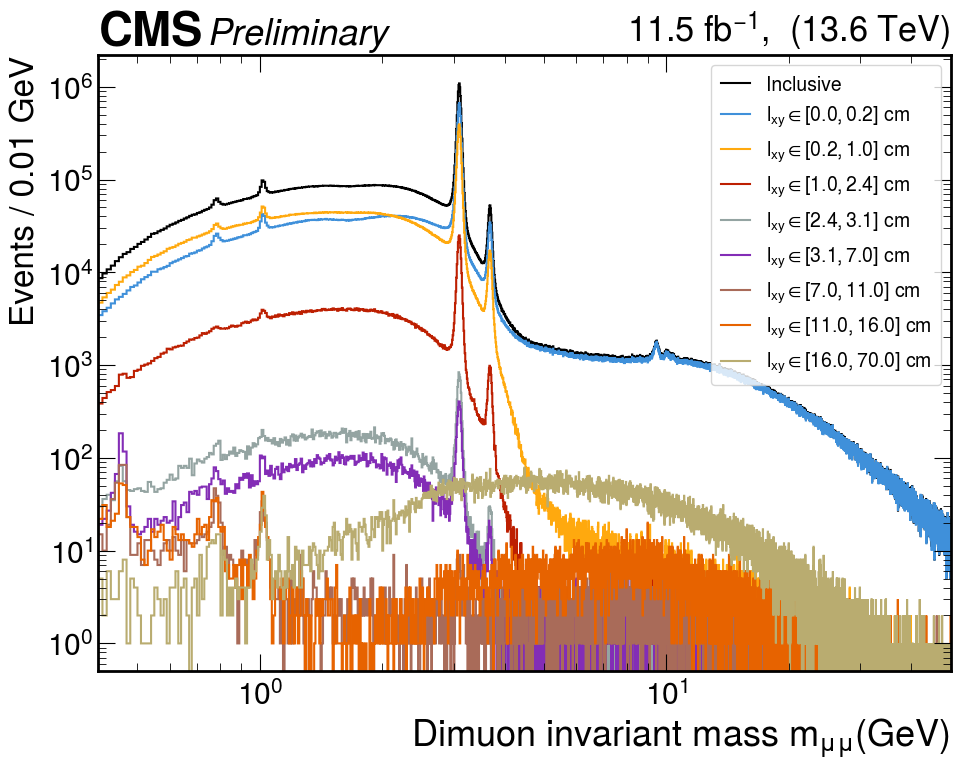

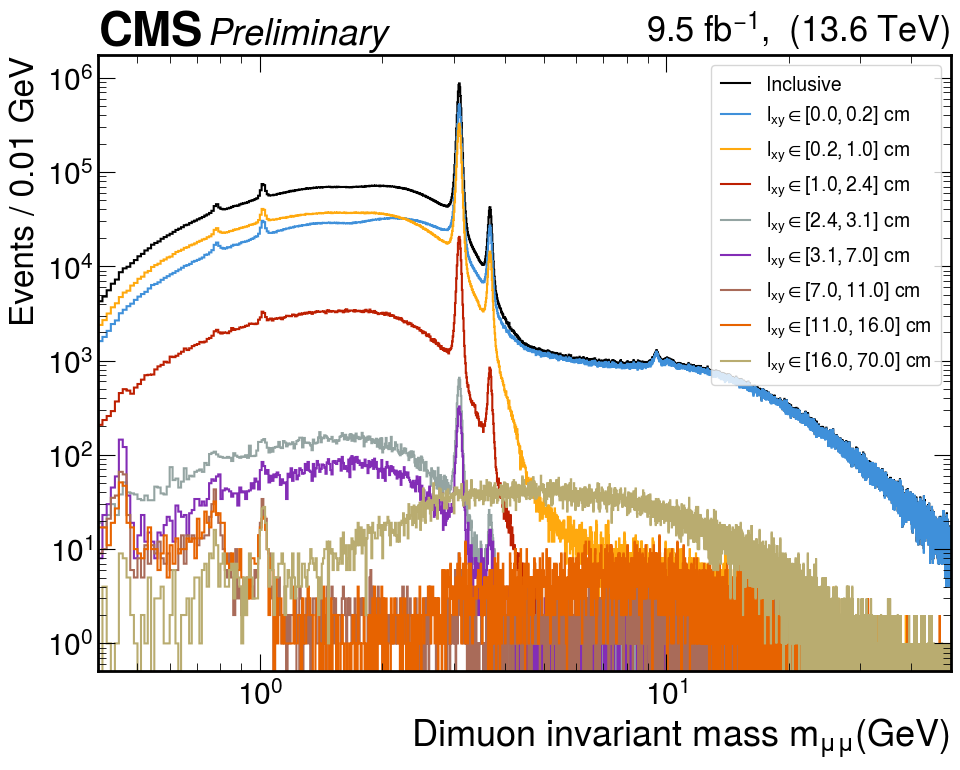

In [14]:
for s in samples:
    sample = s[1]
    period = s[0]
    #
    tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(inDir, sample, period))
    tkeys = tfile.GetListOfKeys()
    #
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlim(0.4, 50)
    #
    hep.cms.label("Preliminary", data=True, year='', lumi = "%.1f"%lumi["%s_%s"%(period,sample)], com='13.6', ax=ax)
    #
    for h,hn in enumerate(hnn):
        th1f = tfile.Get(hn + '_rawmass')
        dhist, dedges = getValues(th1f)
        hep.histplot(dhist, dedges, color=colors[h], label = legnames[hn], histtype="step", ax=ax)
        #print(sample, hn, th1f.GetEntries())
    ax.set_xlabel('Dimuon invariant mass $m_{\mu\mu} (GeV)$')
    ax.set_ylabel('Events / %.2f GeV'%(dedges[1] - dedges[0]), fontsize=24)
    #
    ax.legend(loc="upper right", fontsize=14, frameon=True)
    fig.savefig("lxyComp_%s_%s_paper.png"%(period, sample), dpi=140) 

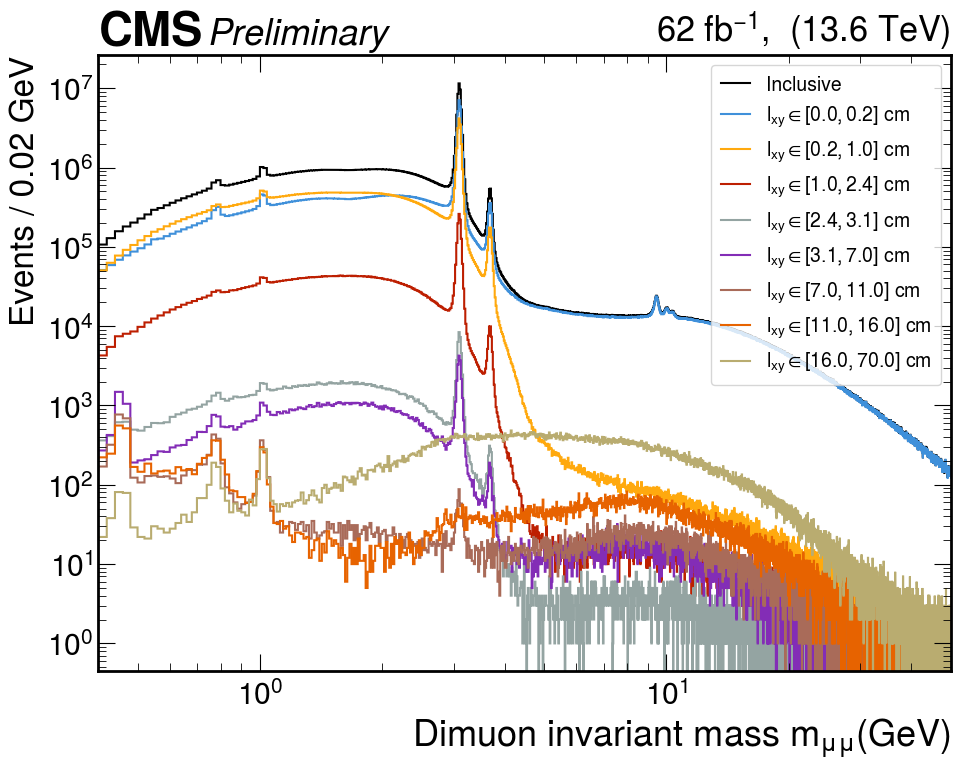

In [6]:
tfile_2022 = ROOT.TFile('/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-23-2025_2022_noMasking/histograms_Data_2022_all.root')
tfile_2023 = ROOT.TFile('/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-23-2025_2023_noMasking/histograms_Data_2023_all.root')
#
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(0.4, 50)
#
hep.cms.label("Preliminary", data=True, year='', lumi = "62", com='13.6', ax=ax)
#
for h,hn in enumerate(hnn):
    th1f      = tfile_2022.Get(hn + '_rawmass')
    th1f_2023 = tfile_2023.Get(hn + '_rawmass')
    th1f.Add(th1f_2023)
    th1f.Rebin(2)
    dhist, dedges = getValues(th1f)
    hep.histplot(dhist, dedges, color=colors[h], label = legnames[hn], histtype="step", ax=ax)
    #print(sample, hn, th1f.GetEntries())
ax.set_xlabel('Dimuon invariant mass $m_{\mu\mu} (GeV)$')
ax.set_ylabel('Events / %.2f GeV'%(dedges[1] - dedges[0]), fontsize=24)
#
ax.legend(loc="upper right", fontsize=14, frameon=True)
fig.savefig("lxyComp_total_Data_paper.png", dpi=400) 

DataC 16316911.0
DataD 9135957.0
DataE 17460316.0
DataF 45527710.0
DataG 7474782.0
DataC 9245069.0
DataD 5471019.0
DataE 9404472.0
DataF 25444565.0
DataG 4040921.0
DataC 6541029.0
DataD 3376589.0
DataE 7435873.0
DataF 18472147.0
DataG 3153991.0
DataC 485298.0
DataD 261908.0
DataE 565722.0
DataF 1433241.0
DataG 247508.0
DataC 20031.0
DataD 11344.0
DataE 22532.0
DataF 60589.0
DataG 10165.0
DataC 11509.0
DataD 6699.0
DataE 12565.0
DataF 35675.0
DataG 5920.0
DataC 1579.0
DataD 910.0
DataE 1904.0
DataF 6587.0
DataG 1266.0
DataC 2412.0
DataD 1425.0
DataE 2965.0
DataF 12059.0
DataG 2382.0
DataC 9984.0
DataD 6063.0
DataE 14283.0
DataF 62847.0
DataG 12629.0


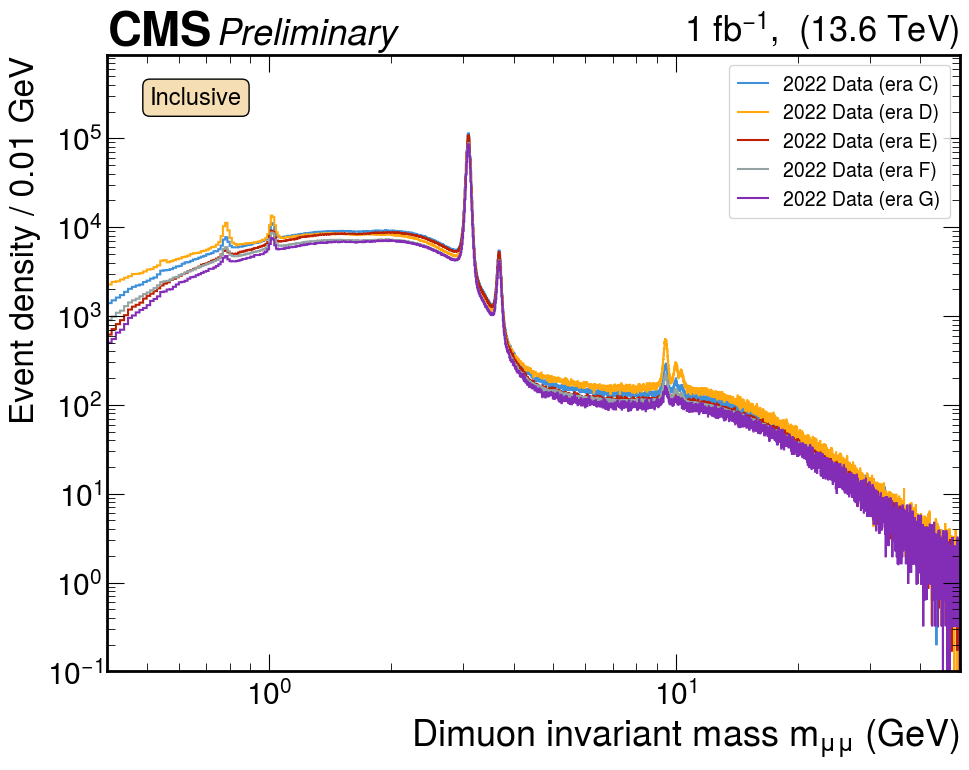

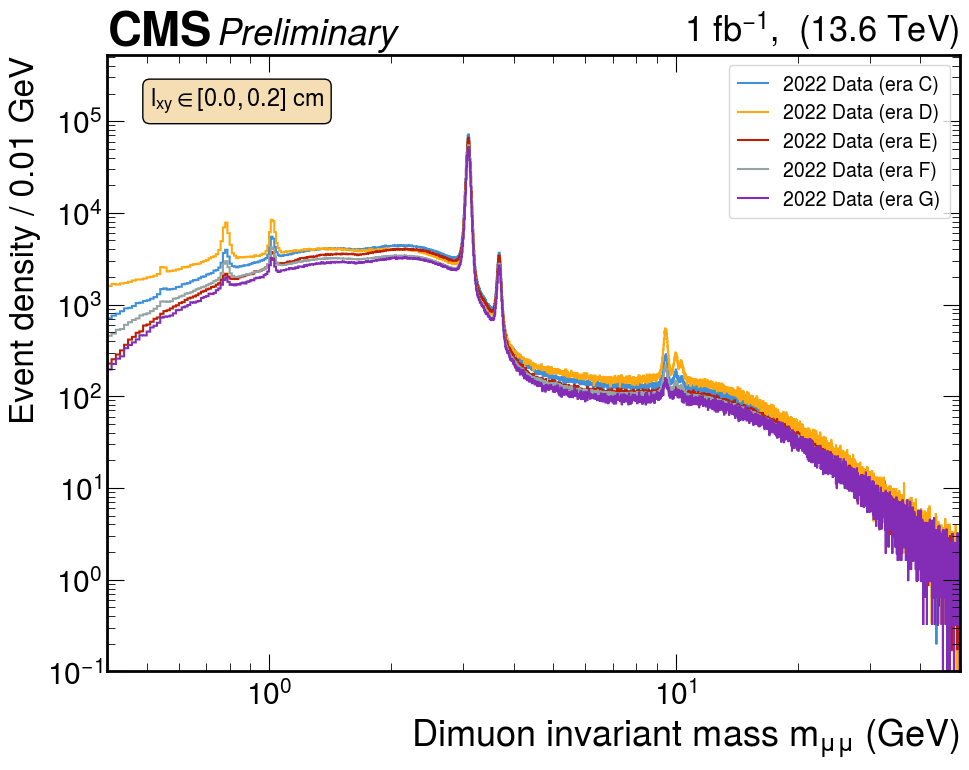

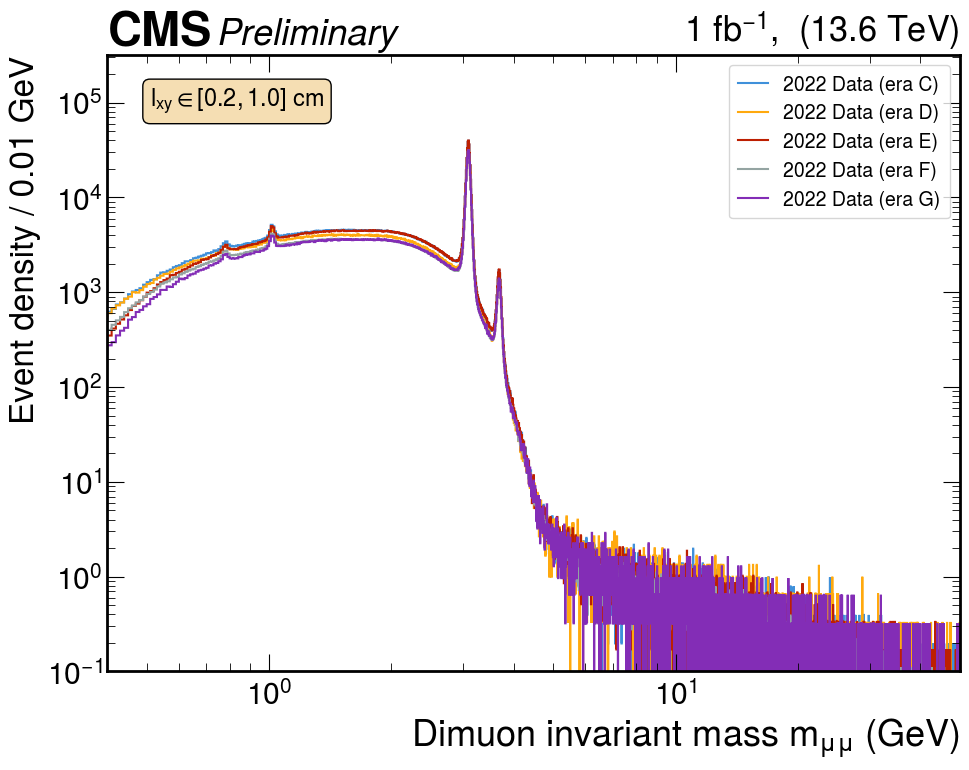

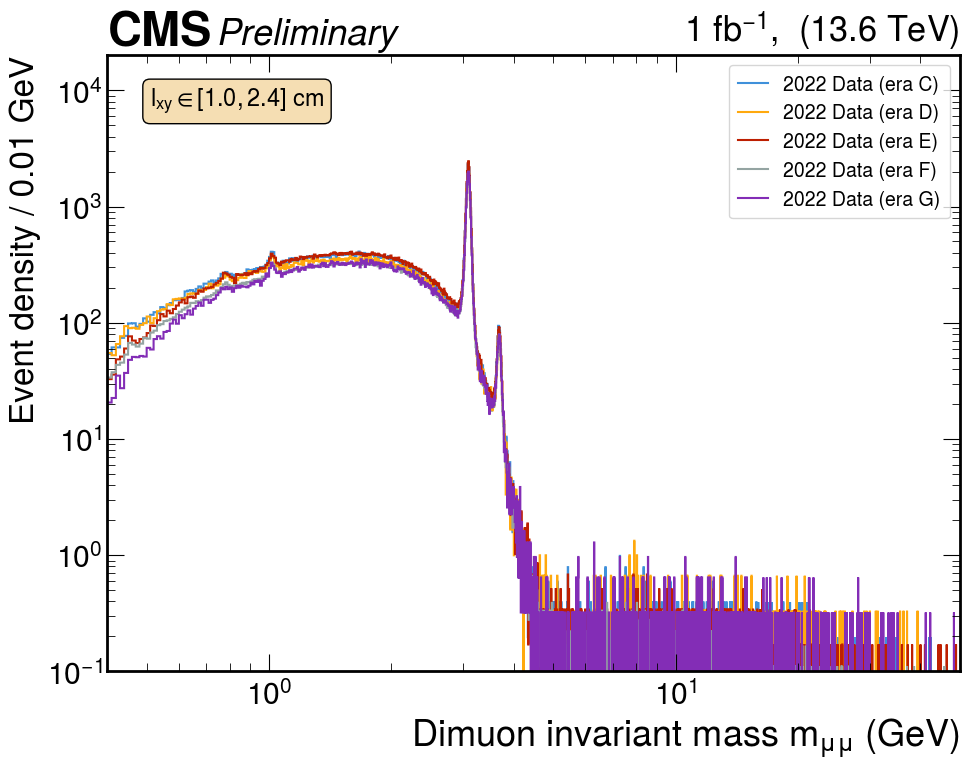

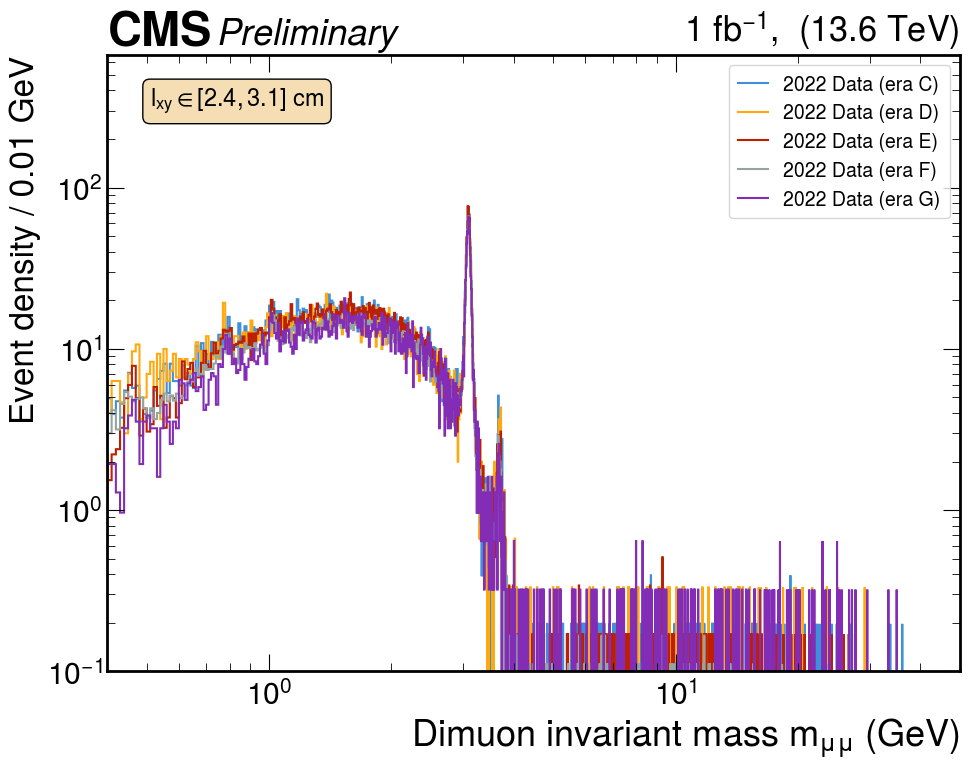

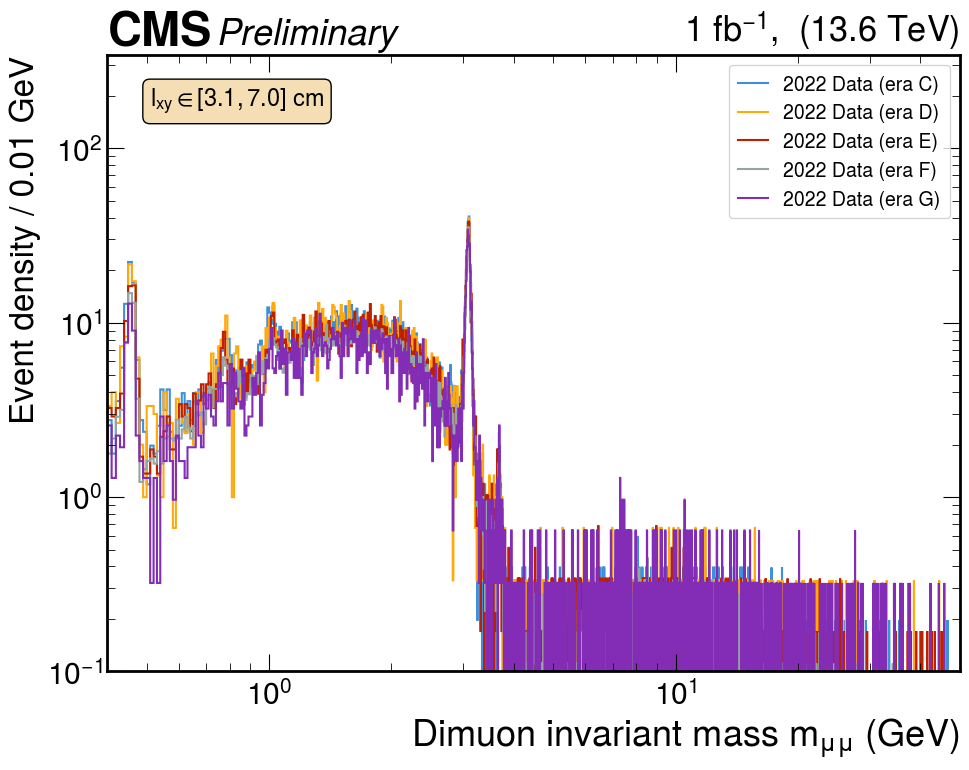

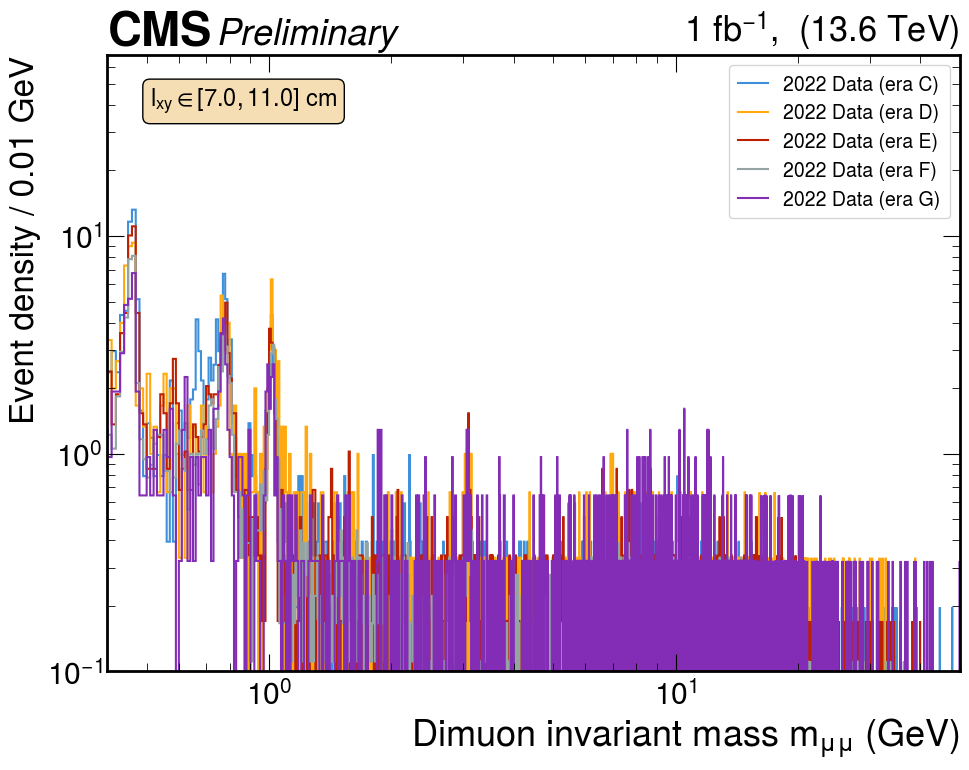

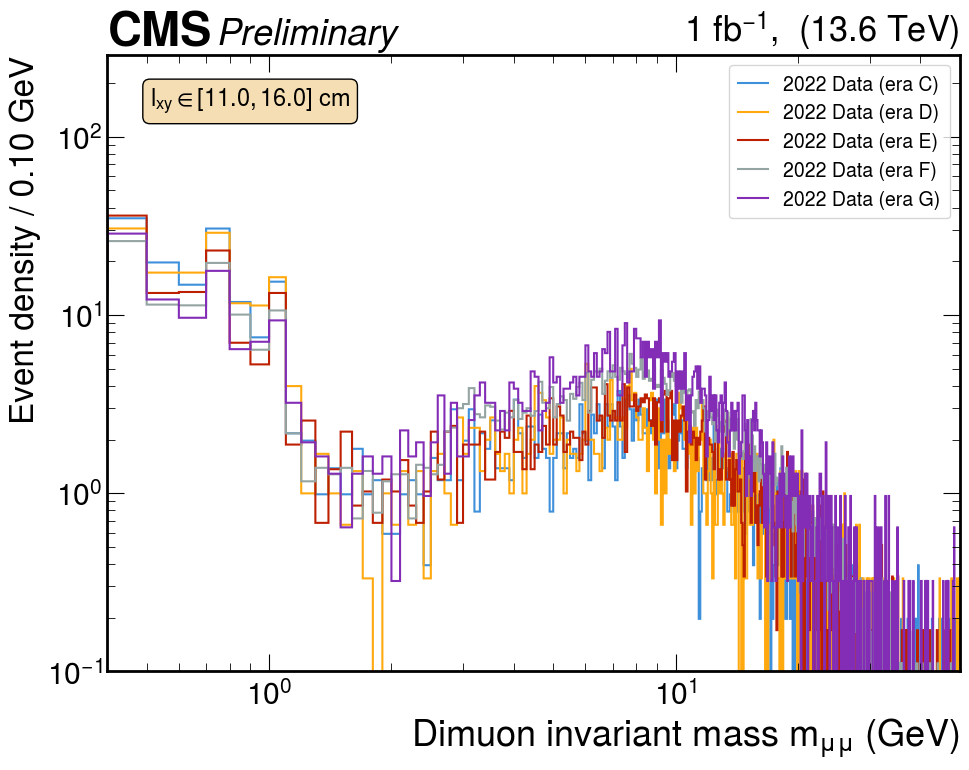

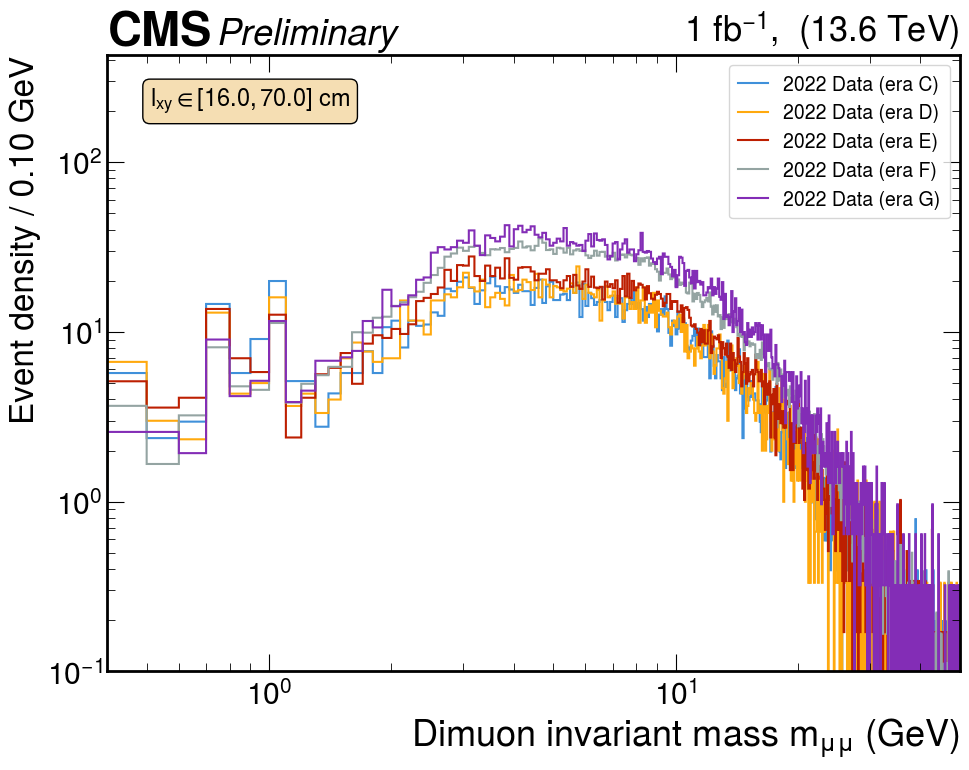

In [17]:
samples.remove('Data')

for hn in hnn:
    #
    tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(inDir, sample, period))
    #
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    ax.set_yscale("log")
    ax.set_xscale("log")
    #
    hep.cms.label("Preliminary", data=True, year='', lumi = "1", com='13.6', ax=ax)
    #
    for s,sample in enumerate(samples):
        tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(inDir, sample, period))
        th1f = tfile.Get(hn + '_rawmass')
        print(sample, th1f.GetEntries())
        th1f.Scale(1./lumi["%s_%s"%(period,sample)])
        if '70p0' in hn or '16p0' in hn:
            th1f.Rebin(10)
        dhist, dedges = getValues(th1f)
        hep.histplot(dhist, dedges, color=colors[1:][s], label = legnames["%s_%s"%(period, sample)], histtype="step", ax=ax)
    ax.set_ylabel('Event density / %.2f GeV'%(dedges[1] - dedges[0]), fontsize=24)
    #
    props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
    ax.text(0.05, 0.95, legnames[hn], transform=ax.transAxes, fontsize=17, verticalalignment='top',horizontalalignment='left', bbox=props)
    #
    ax.set_xlim(0.4, 50)
    ax.set_ylim(0.1, 10*max(dhist))
    ax.set_xlabel(r'Dimuon invariant mass $m_{\mu\mu}$ (GeV)')
    #
    ax.legend(loc="upper right", fontsize=14, frameon=True)
    fig.savefig("eraComp_%s_%s_paper.png"%(period, hn), dpi=140) 

# Data studies in the 4-mu region for different cuts

To check how the data decreases with the application of the following cuts:

/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:499: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el8_amd64_gcc10/external/py3-numpy/1.22.4-62e28bace1c65ef46c4a0988f2d65108/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


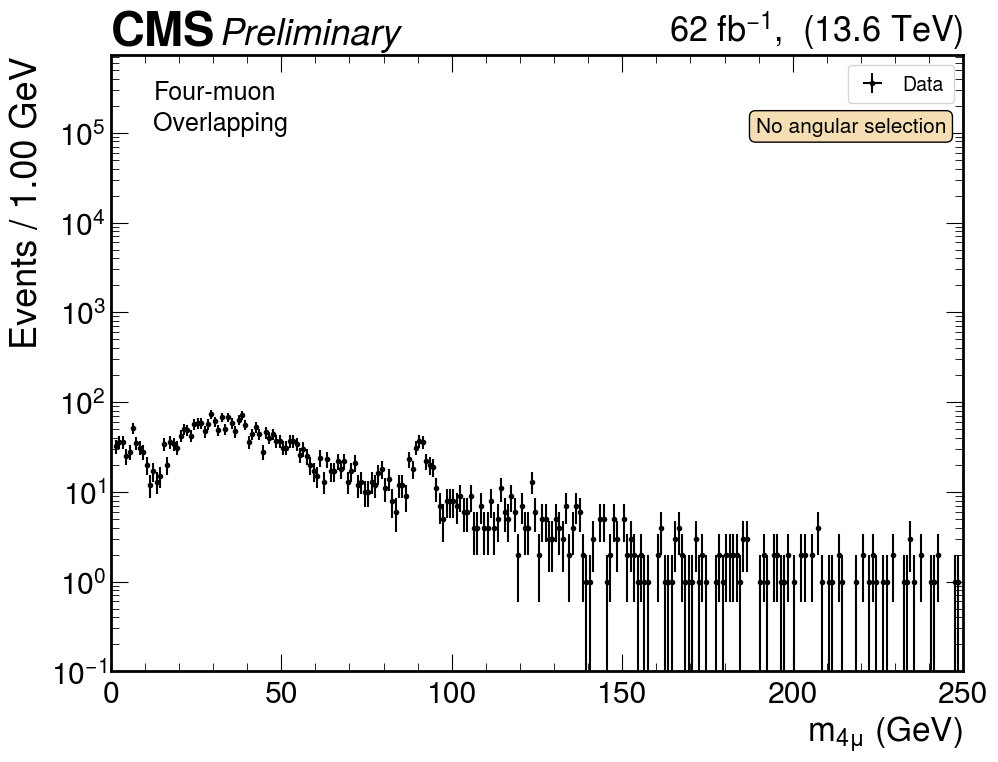

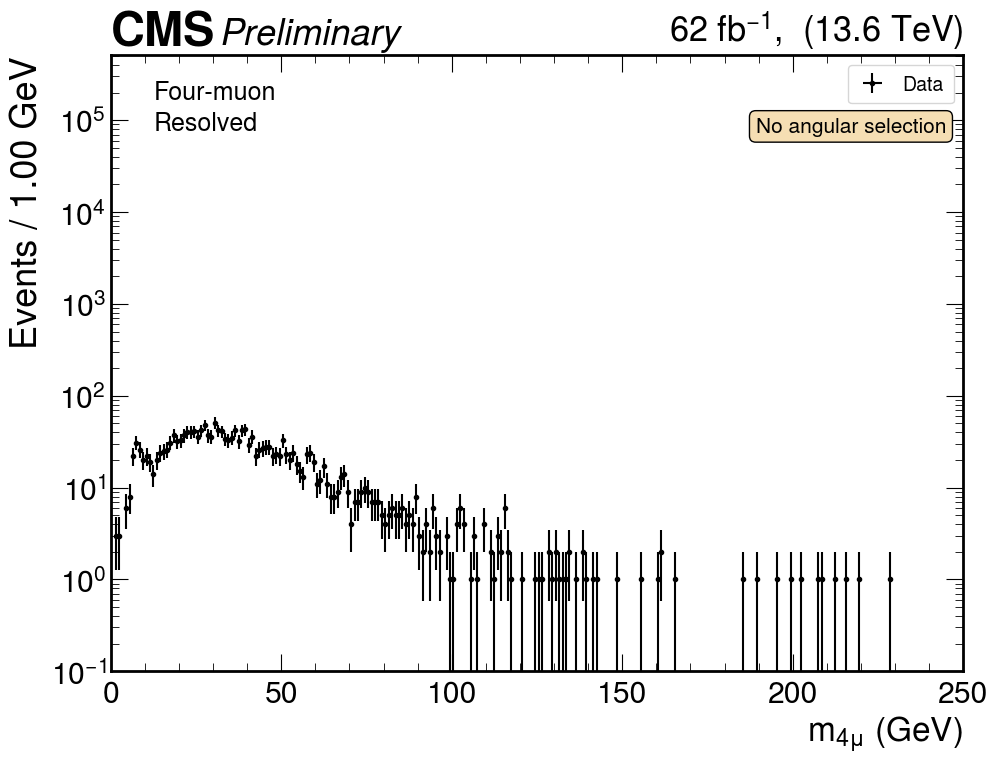

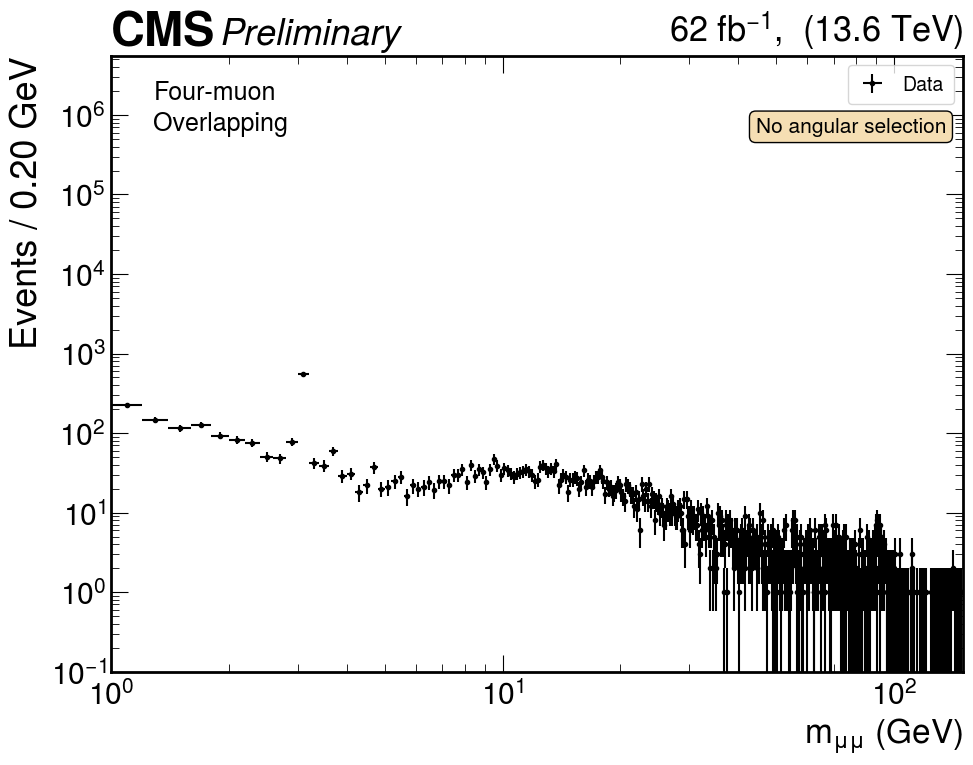

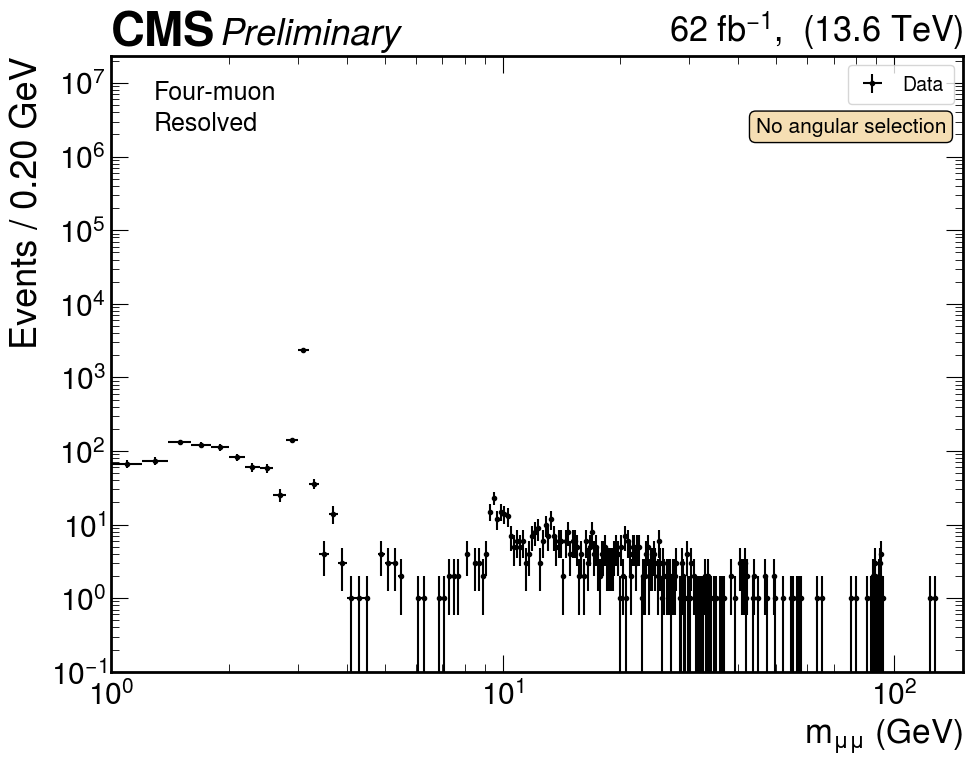

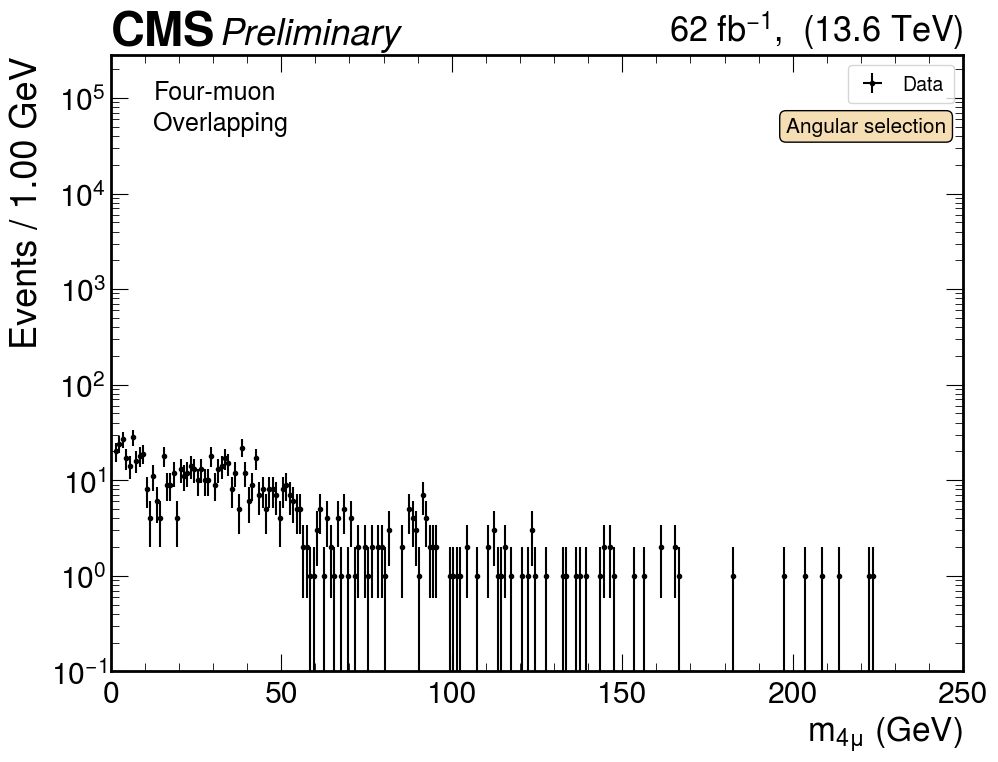

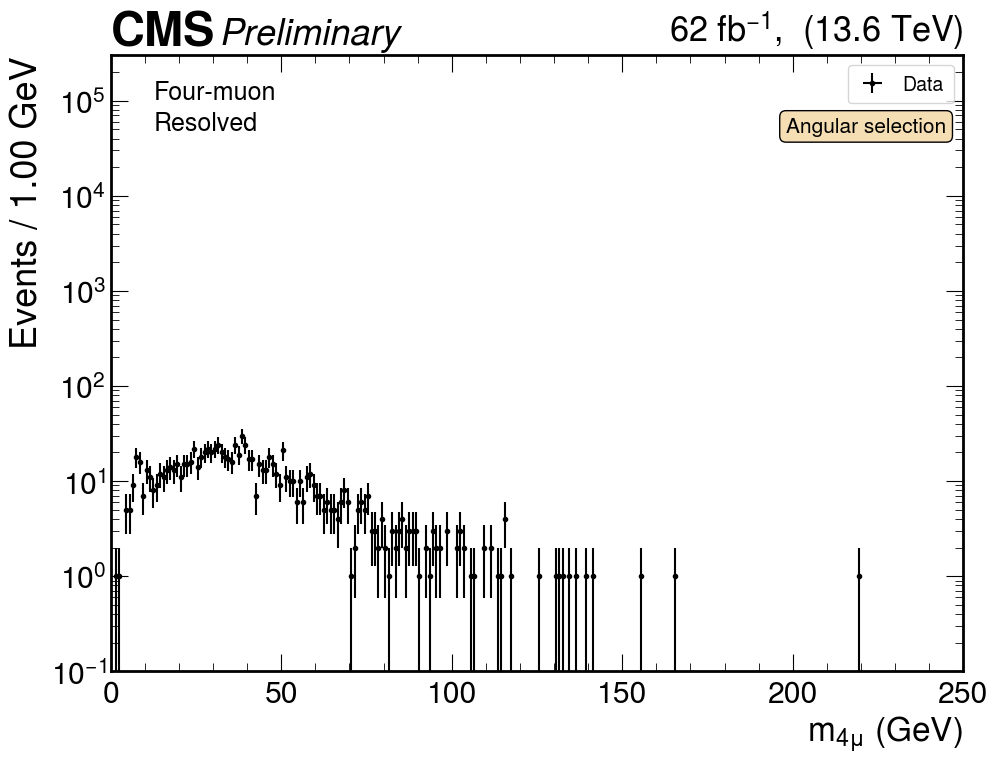

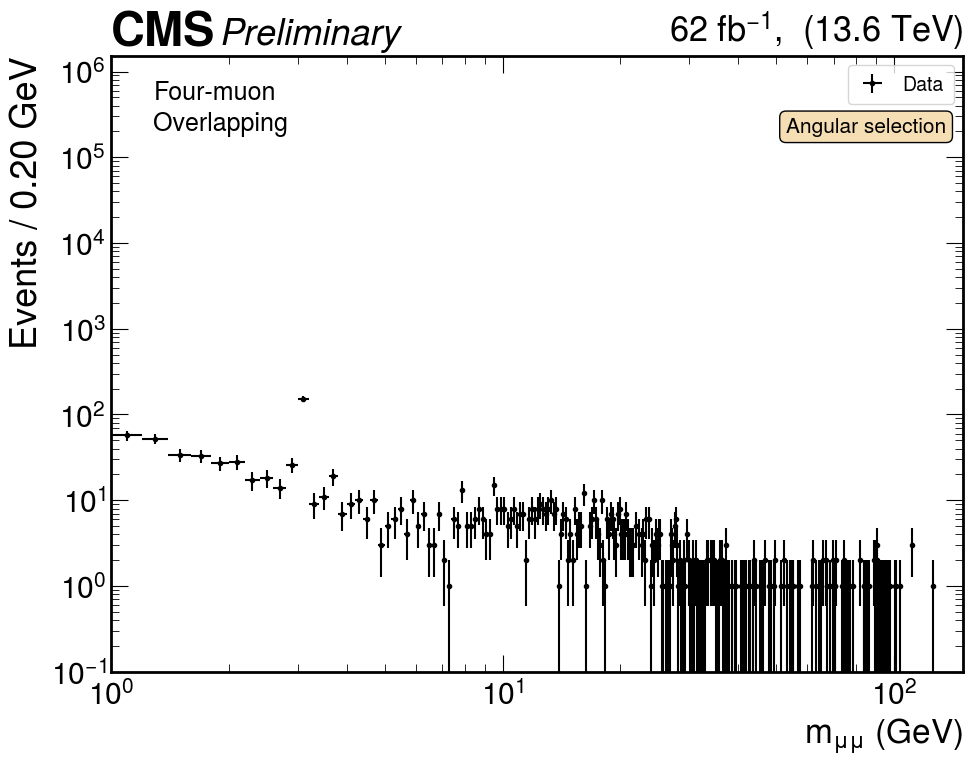

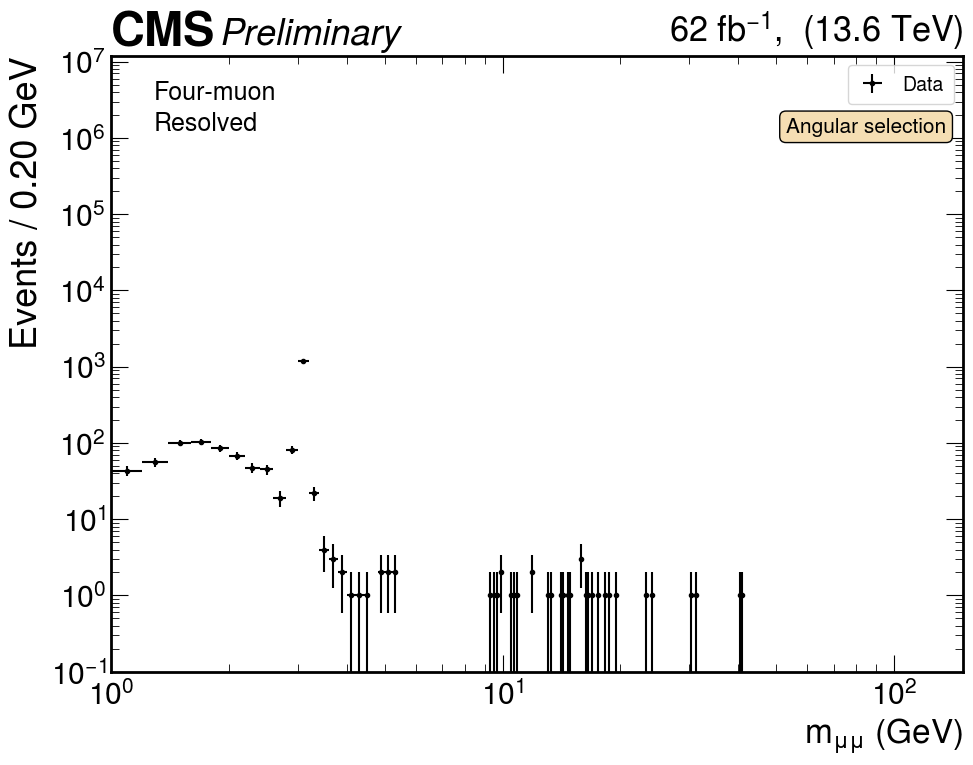

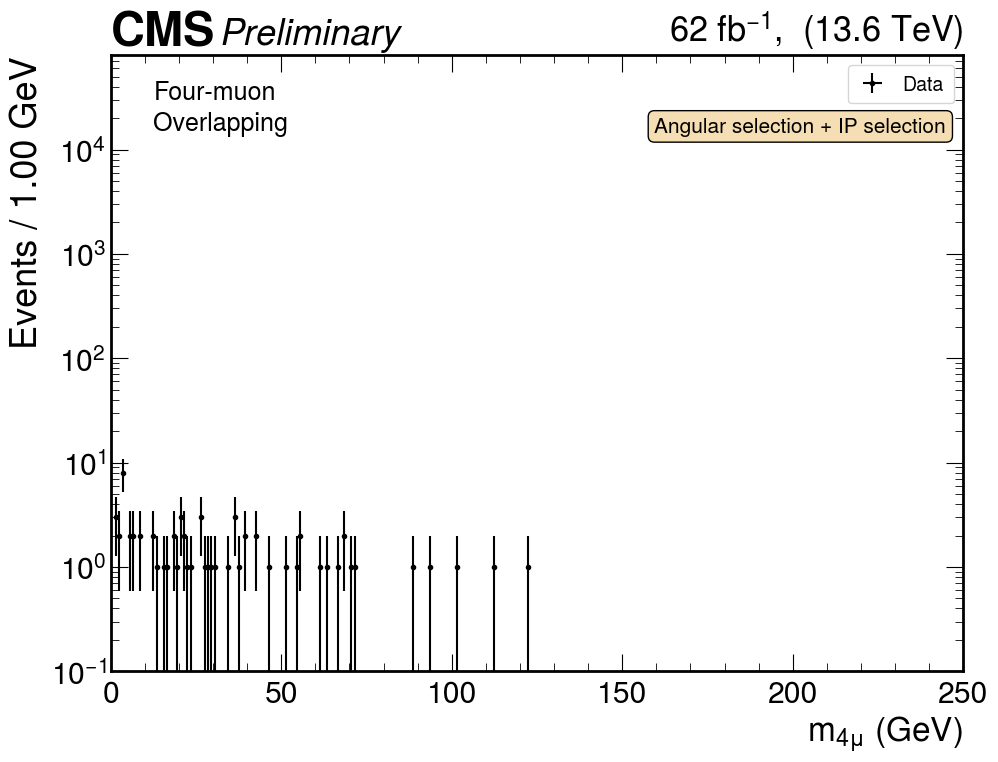

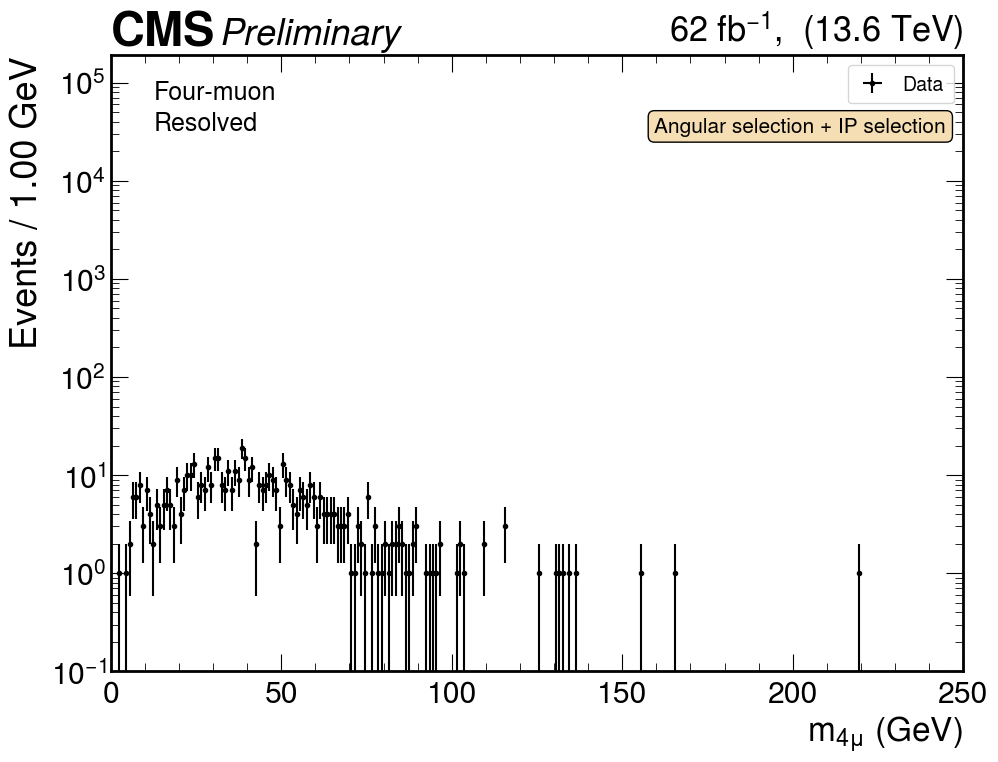

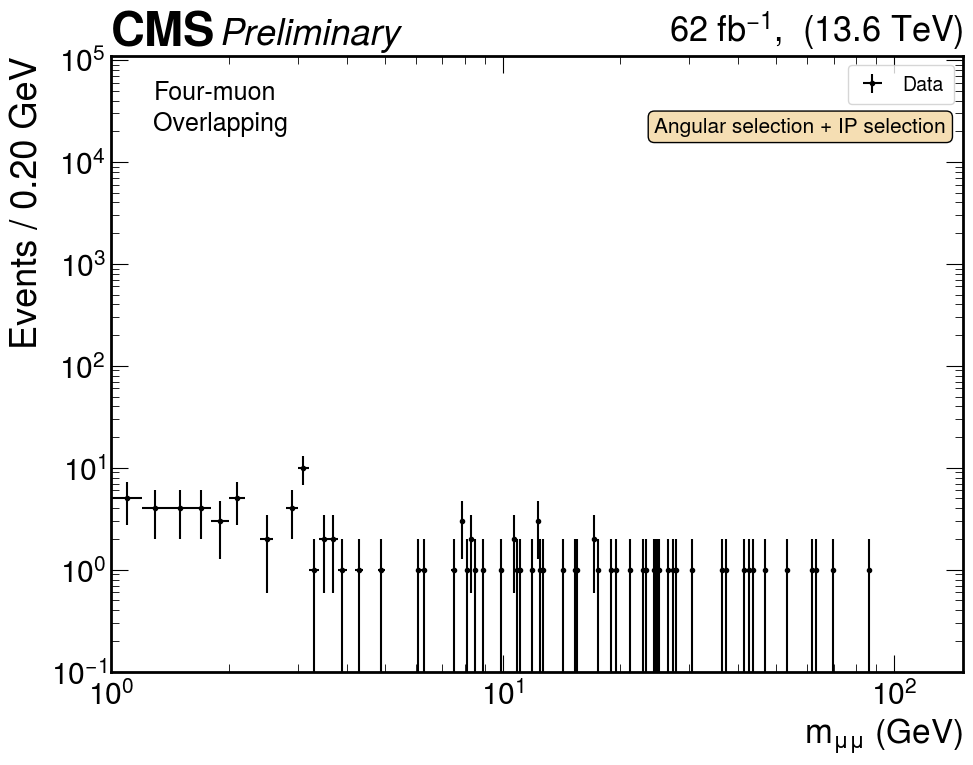

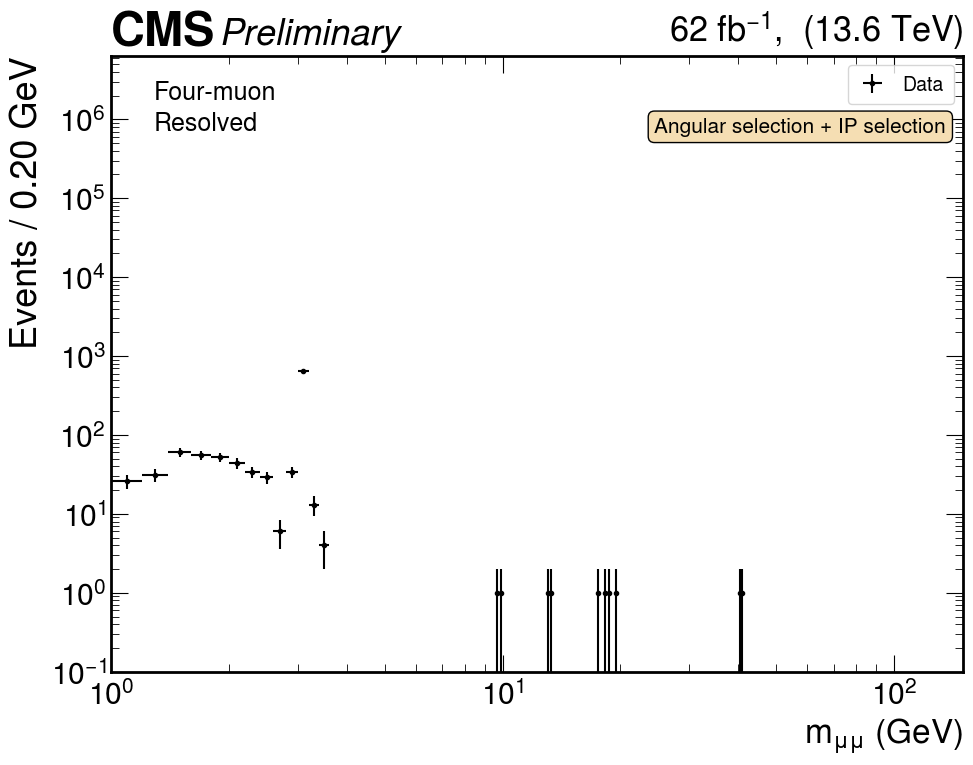

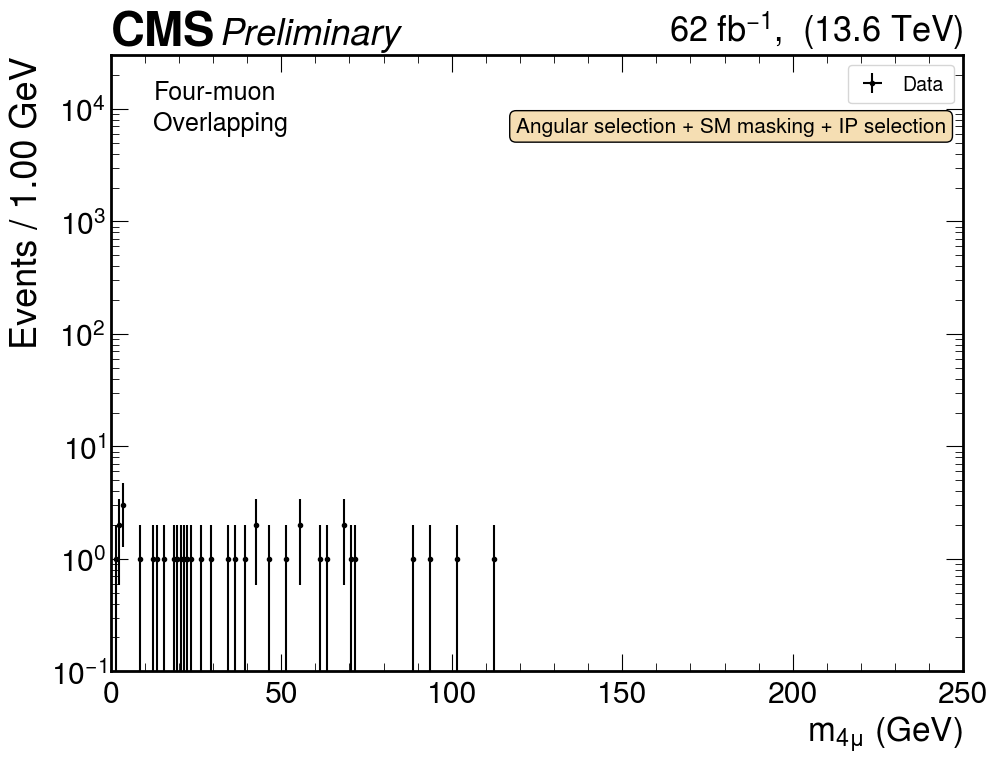

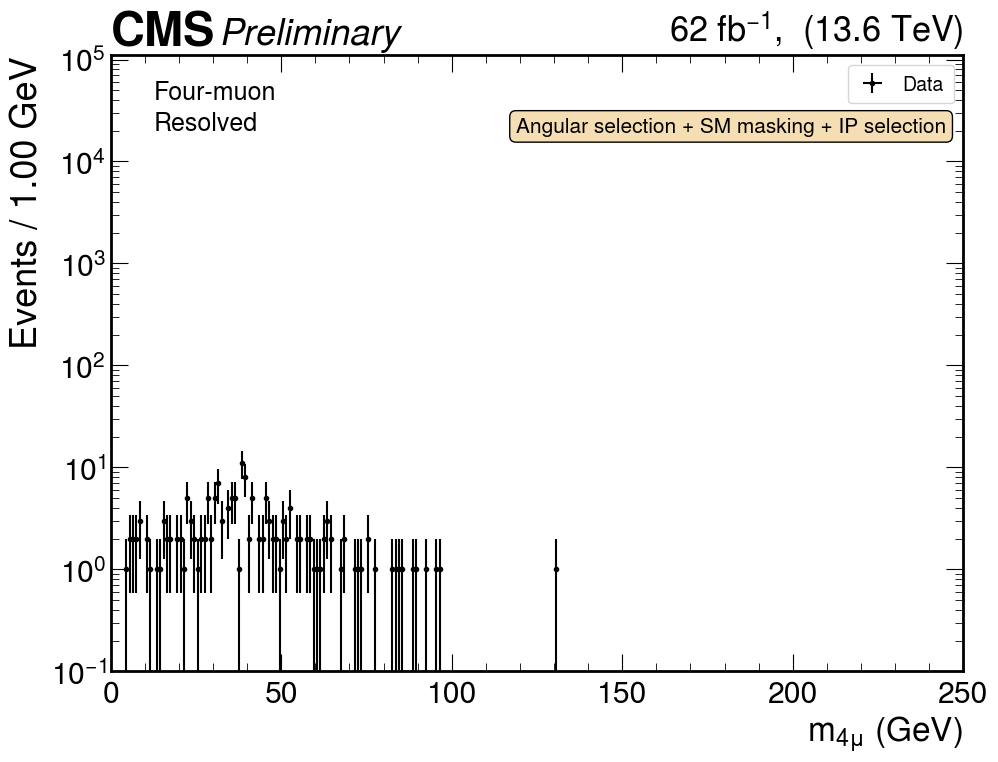

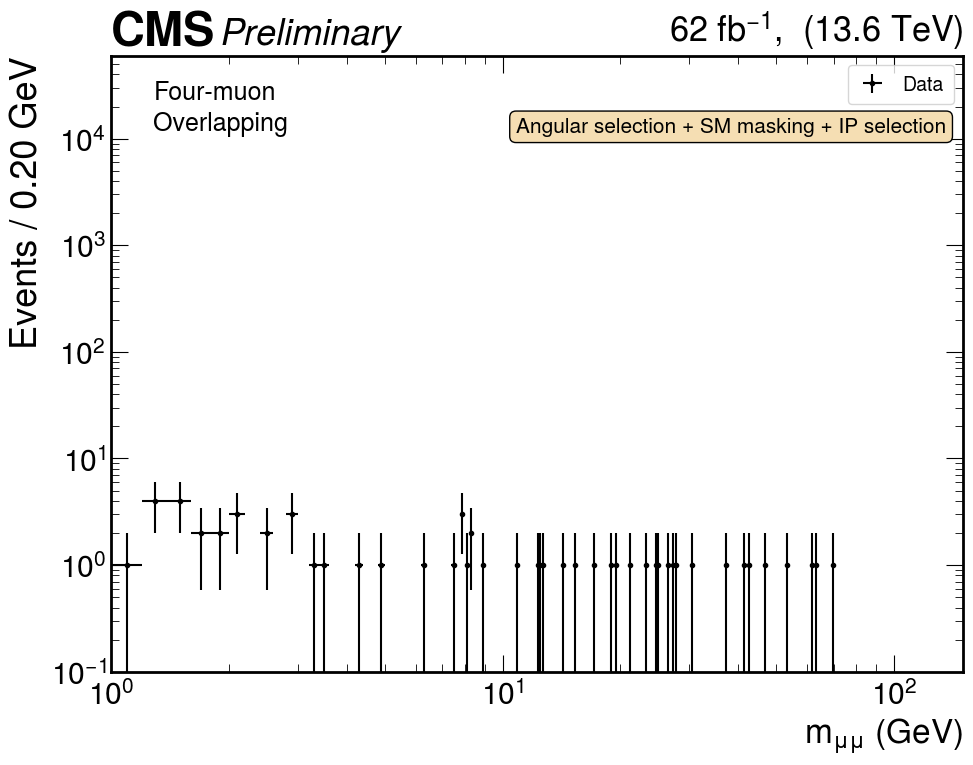

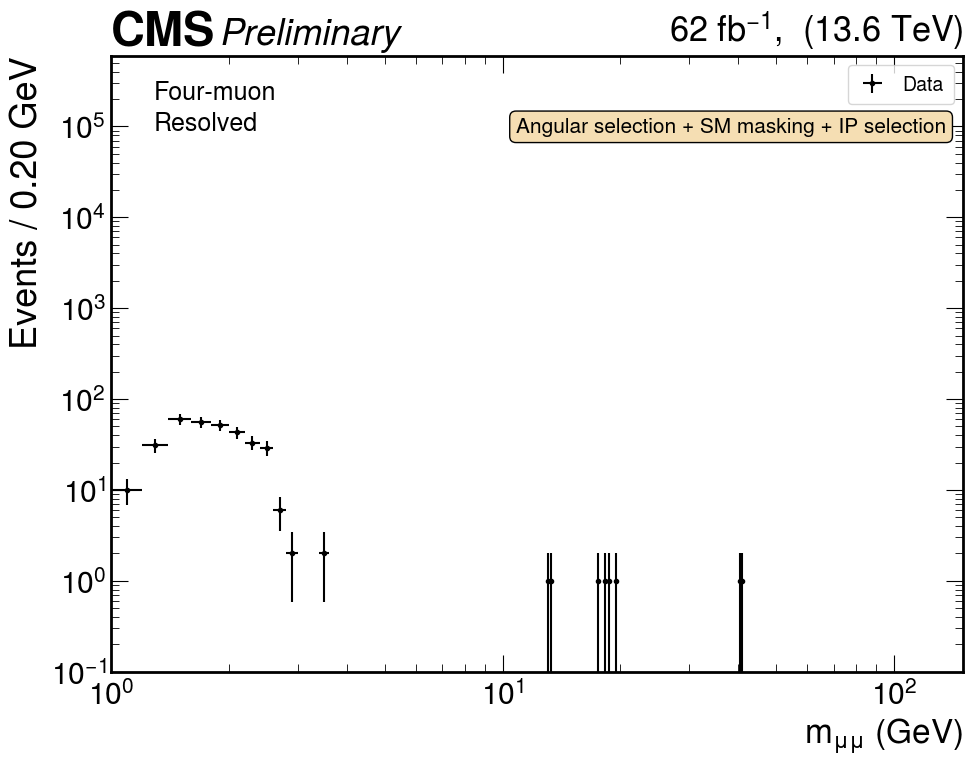

In [2]:
basedir = '/ceph/cms/store/user/fernance/EXO-24-016/Spectra/FourMuon-SelectionStudy/'
cuts = []
cuts.append(['noMask_noIP_noAngular', 'histograms_noMask_noIP_noAngular/', 'No angular selection'])
cuts.append(['noMask_noIP', 'histograms_noMask_noIP/', 'Angular selection'])
cuts.append(['noMask',      'histograms_noMask/', 'Angular selection + IP selection'])
cuts.append(['allCuts',     'histograms_allCuts/', 'Angular selection + SM masking + IP selection'])

hnn = ['d_FourMu_osv_rawmass', 'd_FourMu_sep_rawmass', 'd_FourMu_osv_dimuonmass_rawmass', 'd_FourMu_sep_dimuonmass_rawmass']

for cut in cuts:
    inDir = basedir + cut[1]
    for hn in hnn:
        tfile = ROOT.TFile('%s/histograms_Data_allYears_all.root'%(inDir))
        th1f = tfile.Get(hn)
        if 'dimuonmass' not in hn:
            th1f.Rebin(10)
        else:
            th1f.Rebin(2)
        fig, ax = plt.subplots(1, 1, figsize=(11, 8))
        hep.cms.label("Preliminary", data=True, year='', lumi = 62, com='13.6', ax=ax)
        # 
        # y-log scale always by default
        ax.set_yscale("log")
        ax.set_xscale("log")
        #
        # Data histogram
        dhist, dedges = getValues(th1f)
        y_err = dhist**0.5
        ddedges = []
        for v in range(0, len(dedges)-1):
            ddedges.append(dedges[v] + 0.5*(dedges[v+1] - dedges[v]))
        ax.errorbar(np.array(ddedges), dhist, yerr=y_err, xerr=0.5*(dedges[1] - dedges[0]), fmt='o', label='Data', color='k', markersize=3, zorder=5)
        ax.set_ylim(0.1, 10000*max(dhist))
        #
        #
        if "d_Dimuon" in hn:
            ax.set_xlim(0.20, 50.0)
            ax.set_xlabel(r'$m_{\mu\mu}$ (GeV)', fontsize=24)
            catnames = hn.split("_")
            if "excluded" in hn:
                ax.text(0.05, 0.96, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                ax.text(0.05, 0.86, "Excluded", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
            elif 'inclusive' in hnn:
                ax.text(0.05, 0.96, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                ax.text(0.05, 0.86, "Inclusive", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
            else:
                ax.text(0.05, 0.96, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                lxybin = catnames[2]
                lxybin = (lxybin[3:]).split("to")
                ax.text(0.05, 0.91, r"$l_{{xy}} \in [{},{}]$".format(lxybin[0].replace("p", "."), lxybin[1].replace("p", ".")), fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                if "non-pointing" not in hn:
                    isobin = "Isolated" if catnames[3]=="iso1" else "Non isolated"
                    ax.text(0.05, 0.86, isobin, fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                    ptbin = r"High $p_{T}^{\mu\mu}$" if catnames[4]=="pthigh" else r"Low $p_{T}^{\mu\mu}$"
                    ax.text(0.05, 0.81, ptbin, fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
                else:
                    ax.text(0.05, 0.86, "Non-pointing", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
            ax.axvspan(0.41, 0.50, color='lightgray', alpha=1.0, zorder=1) # Ks
            ax.axvspan(0.51, 0.59, color='lightgray', alpha=1.0, zorder=1) # Eta
            ax.axvspan(0.73, 0.83, color='lightgray', alpha=1.0, zorder=1) # rho/w
            ax.axvspan(0.96, 1.08, color='lightgray', alpha=1.0, zorder=1) # phi
            ax.axvspan(2.91, 3.27, color='lightgray', alpha=1.0, zorder=1) # JPsi
            ax.axvspan(2.89, 3.33, color='lightgray', alpha=1.0, zorder=1) # JPsi
            ax.axvspan(3.47, 3.94, color='lightgray', alpha=1.0, zorder=1) # PSi2S
            ax.axvspan(8.88, 10.85, color='lightgray', alpha=1.0, zorder=1) # Upsilon
        elif "d_FourMu" in hn:
            ax.set_xscale('linear')
            ax.set_xlim(0, 250)
            ax.set_xlabel(r'$m_{4\mu}$ (GeV)', fontsize=24)
            ax.text(0.05, 0.96, "Four-muon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
            fourmucat = "Resolved" if "sep" in hn else "Overlapping"
            ax.text(0.05, 0.91, fourmucat, fontsize=18, color='black', horizontalalignment='left', verticalalignment='top', transform=ax.transAxes) 
        if 'dimuonmass' in hn:
            ax.set_xscale('log')
            ax.set_xlim(1., 150.0)
            ax.set_xlabel(r'$m_{\mu\mu}$ (GeV)', fontsize=24)
        ax.set_ylabel('Events / %.2f GeV'%(dedges[1] - dedges[0]))
        #
        props = dict(boxstyle='round', facecolor='wheat', alpha=1.0)
        ax.text(0.98, 0.9, cut[2], transform=ax.transAxes, fontsize=15, verticalalignment='top',horizontalalignment='right', bbox=props)
        #
        ax.legend(loc="upper right", fontsize=14, frameon=True)
        fig.savefig("%s_%s_paper.png"%(hn, cut[0]), dpi=140) 